## Best model (after hyperparameter tuning)

In this notebook, we analyze the best tft model obtained after hyperparameter tuning. 

In [35]:
import os


In [36]:
# General
import gc
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import json
from pathlib import Path
import pickle
import itertools

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

# From PyTorch
import torch
from torch.nn import BCEWithLogitsLoss
from torchmetrics.classification import AveragePrecision
from lightning.pytorch.callbacks import ModelCheckpoint

# From PyTorch Forecasting
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import CrossEntropy, Metric
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from pytorch_forecasting.tuning import Tuner
from pytorch_forecasting.metrics import MultiHorizonMetric

# From sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,precision_recall_curve,confusion_matrix,
classification_report)


# Selecting device
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = get_device()
print(f"Using device ; {device}")

if device=='cuda':
    print(torch.cuda.get_device_name(0))

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    pl.seed_everything(seed, workers=True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

def clean_up():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

class BCEWithLogitsLossWrapper(MultiHorizonMetric):
    def __init__(self,pos_weight=None):
        super().__init__()
        self.criterion = BCEWithLogitsLoss(pos_weight=pos_weight)

    def loss(self, y_pred, target):
        # if model outputs [batch, 1] or [batch, 1, 1]
        y_pred = y_pred.squeeze(-1)
        return self.criterion(y_pred, target.float())


class PRAUCMetric(Metric):
    def __init__(self):
        super().__init__()
        self.metric = AveragePrecision(task="binary")

    def update(self, preds, target):


        preds = torch.sigmoid(preds.squeeze(-1)).view(-1)


        if isinstance(target, (tuple, list)):
            target = target[0]

        target = target.view(-1)
        target = target.long()

        self.metric.update(preds, target)

    def compute(self):
        return self.metric.compute()


lookback = 24
learning_rate = 3e-4
max_epochs = 30
patience = 5
batch_size = 64
max_prediction_length = 1

# Relevant timestamps
valid_start = pd.Timestamp("2025-07-01", tz="UTC")
test_start = pd.Timestamp("2025-12-01", tz="UTC")


Seed set to 42


Using device ; mps


### Creating dataset and dataloaders

In [37]:
# Loading processed data
df_feature_file = (pd.read_csv(f"feature_combined_data_2019-05-01_2026-05-01.csv",parse_dates=["timestamp_utc"]
                            ).set_index("timestamp_utc").sort_index())
df_forecast = ( pd.read_csv(f"forecast_data_2024-03-01_2026-05-02.csv",parse_dates=["timestamp_utc"]
                            ).set_index("timestamp_utc").sort_index())

df_feature_file['time_idx'] =  np.arange(len(df_feature_file))
calendar_cols = ["hour_sin","hour_cos","day_of_week_sin","day_of_week_cos","month_sin","month_cos",]

observed_cols = [c for c in df_feature_file.columns if c.startswith("observed_")]
forecast_cols = [c for c in df_forecast.columns if c.startswith("forecast_")]
smard_input_cols = [c for c in df_feature_file.columns if c not in calendar_cols + ["Negative_price"] + observed_cols]

observed_weather = df_feature_file[observed_cols].rename(columns=lambda c: c.replace("observed_", ""))
forecast_weather = df_forecast[forecast_cols].rename(columns=lambda c: c.replace("forecast_", ""))

if sorted(observed_weather.columns) != sorted(forecast_weather.columns):
    raise ValueError("Observed and forecast weather columns do not match after removing prefixes")

target = "Negative_price"
weather_cols = list(df_forecast.columns)
reals = calendar_cols + smard_input_cols + weather_cols
scalers = {feature: StandardScaler()for feature in reals}
time_varying_known_reals = (calendar_cols + weather_cols)
time_varying_unknown_reals = smard_input_cols



In [38]:
def build_tft_dataset(df_feature,df_forecast,calendar_cols,smard_input_cols,test_start,lookback=24):

    # Align time range
    start_date = max(df_feature.index.min(), df_forecast.index.min())

    df = df_feature.loc[start_date:test_start].copy()
    df_weather = df_forecast.loc[start_date:test_start].copy()

    # Remove observed weather 
    df = df.drop(columns=[c for c in df.columns if c.startswith("observed_")])

    # Join forecast weather (aligned to time t)
    df = df.join(df_weather, how="inner")

    # Target: predict t+24 negative price
    df["target"] = df["Negative_price"].shift(-24)

    # Shift forecast weather to the same prediction horizon
    forecast_cols = df_forecast.columns
    df[forecast_cols] = df[forecast_cols].shift(-24)
    
    # Remove rows where either the target or shifted weather is missing
    df = df.dropna(subset=["target"] + list(forecast_cols)).copy()

    # Clean duplicates
    df = df.loc[:, ~df.columns.duplicated()]

    # Rebuild time index
    df = df.drop(columns=["time_idx"], errors="ignore")
    df["time_idx"] = np.arange(len(df))

    df["series"] = 0

    # Feature columns
    cols = (
        calendar_cols
        + smard_input_cols
        + list(df_forecast.columns)
        + ["time_idx", "series", "target"]
    )
    cols = list(dict.fromkeys(cols))

    df_tft = df[cols]

    # Train / full pre-test split
    data = df_tft[df_tft.index < test_start]

    # include enough history for encoder + horizon
    test_data = df_tft[
        df_tft.index >= (test_start - pd.Timedelta(hours=lookback+24 ))
    ].copy()

    return df_tft, data, test_data

In [39]:
df_tft, data, test_data = build_tft_dataset(df_feature_file,df_forecast,calendar_cols,
                                            smard_input_cols,test_start,lookback=lookback)

train_data = data[data.index < valid_start]

training = TimeSeriesDataSet(train_data,time_idx="time_idx",target="target",group_ids=["series"],
                              max_encoder_length=lookback,max_prediction_length=1,
                              time_varying_known_reals=time_varying_known_reals,
                              time_varying_unknown_reals=time_varying_unknown_reals,
                              add_relative_time_idx=True,add_target_scales=False,add_encoder_length=True,)

validation_data = data[(data.index >= valid_start) & (data.index < test_start)]

validation = TimeSeriesDataSet.from_dataset(training,validation_data,stop_randomization=True)

test_dataset = TimeSeriesDataSet.from_dataset(training,test_data,stop_randomization=True)

# imbalance handling 
n_pos = train_data["target"].sum()
n_neg = len(train_data) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=2,persistent_workers=True)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

In [40]:
data['target'].sum()/len(data['target'])

np.float64(0.0658538175653648)

## Inspecting the best model

Early stopping based on PR-AUC. Also using BCEWithLogitsLoss with pos_weight

In [45]:

checkpoint = torch.load("tft_h16_a4_d0.2_c16.ckpt",map_location="cpu",weights_only=False)

best_model = TemporalFusionTransformer.from_dataset(training,**checkpoint["hyper_parameters"])
best_model.load_state_dict(checkpoint["state_dict"], strict=False)

for p in best_model.parameters():
    p.data = p.data.cpu()



/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them usin

In [49]:

from sklearn.metrics import (roc_auc_score,average_precision_score,precision_recall_curve,confusion_matrix,)

best_model.eval()

all_probs = []
all_targets = []

with torch.no_grad():
    for x, y in val_loader:

        x = {k: v.cpu() for k, v in x.items()}

        logits = best_model(x).prediction.view(-1)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu())
        all_targets.append(y[0].view(-1).cpu())

probs = torch.cat(all_probs).numpy()
y_true = torch.cat(all_targets).numpy()

roc_auc = roc_auc_score(y_true, probs)
pr_auc = average_precision_score(y_true, probs)

precision, recall, thresholds = precision_recall_curve(y_true, probs)
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

preds = (probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

print(f"ROC-AUC:{roc_auc}")
print(f"PR-AUC:{pr_auc}")
print(f"Best threshold:{best_threshold}")
print(f"Best F1:{best_f1}")
print(f"TN, FP,FN, TP:{(tn, fp, fn, tp)}")

ROC-AUC:0.9027969940487472
PR-AUC:0.7657304899106215
Best threshold:0.9244254231452942
Best F1:0.7374301626016667
TN, FP,FN, TP:(np.int64(3399), np.int64(42), np.int64(52), np.int64(132))


## Where do errors occur?

### Error structure by hour

In [51]:
# timestamps actually used by the validation dataloader
val_index = []

for x, y in val_loader:
    decoder_time_idx = x["decoder_time_idx"].cpu().numpy().reshape(-1)
    val_index.extend(decoder_time_idx)

val_index = np.array(val_index)

# Map time_idx back to timestamps
time_map = validation_data.reset_index()[["time_idx", "timestamp_utc"]]
val_timestamps = (
    pd.DataFrame({"time_idx": val_index})
    .merge(time_map, on="time_idx", how="left")["timestamp_utc"]
)

results = pd.DataFrame({
    "timestamp": val_timestamps.values,
    "y_true": y_true.astype(int),
    "prob": probs,
})

results = results.set_index("timestamp")

results["y_pred"] = (results["prob"] >= best_threshold).astype(int)

results["error_type"] = "TN"
results.loc[(results.y_true == 1) & (results.y_pred == 1), "error_type"] = "TP"
results.loc[(results.y_true == 0) & (results.y_pred == 1), "error_type"] = "FP"
results.loc[(results.y_true == 1) & (results.y_pred == 0), "error_type"] = "FN"

results["hour"] = results.index.hour

In [52]:
results.groupby(["hour","error_type"]).size().unstack(fill_value=0)

error_type,FN,FP,TN,TP
hour,,,,
0,0,1,148,3
1,0,2,146,3
2,0,0,147,4
3,0,1,147,3
4,0,2,147,2
5,0,2,147,2
6,0,1,148,2
7,3,1,144,3
8,9,2,136,4


<Figure size 1200x500 with 0 Axes>

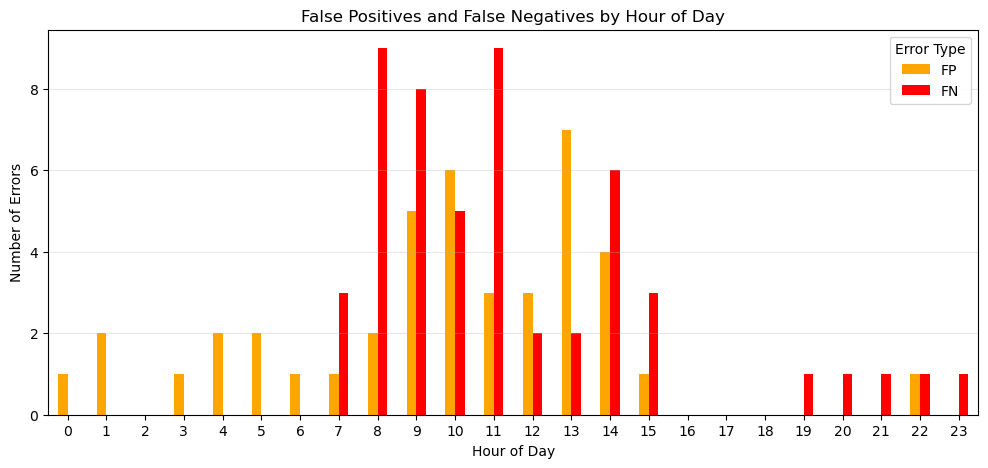

In [53]:


hourly_errors = (
    results.groupby(["hour", "error_type"])
    .size()
    .unstack(fill_value=0)
)

# Keep only error types of interest
hourly_errors = hourly_errors[["FP", "FN"]]

plt.figure(figsize=(12,5))

hourly_errors.plot(
    kind="bar",
    figsize=(12,5),
    color={"FP": "orange", "FN": "red"}
)

plt.title("False Positives and False Negatives by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Errors")
plt.xticks(rotation=0)
plt.legend(title="Error Type")
plt.grid(axis="y", alpha=0.3)

plt.show()

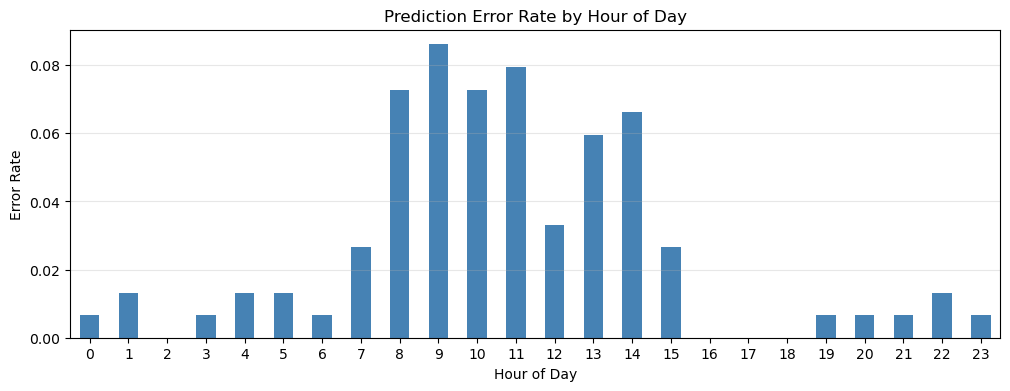

In [54]:
hourly_error_rate = (
    results.groupby("hour")
    .apply(lambda x: (x["error_type"].isin(["FP","FN"])).mean())
)

plt.figure(figsize=(12,4))
hourly_error_rate.plot(kind="bar", color="steelblue")

plt.title("Prediction Error Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Error structure by day

In [101]:
# timestamps actually used by the validation dataloader
val_index = []

for x, y in val_loader:
    decoder_time_idx = x["decoder_time_idx"].cpu().numpy().reshape(-1)
    val_index.extend(decoder_time_idx)

val_index = np.array(val_index)

# Map time_idx back to timestamps
time_map = validation_data.reset_index()[["time_idx", "timestamp_utc"]]
val_timestamps = (
    pd.DataFrame({"time_idx": val_index})
    .merge(time_map, on="time_idx", how="left")["timestamp_utc"]
)

results = pd.DataFrame({
    "timestamp": val_timestamps.values,
    "y_true": y_true.astype(int),
    "prob": probs,
})

results = results.set_index("timestamp")

results["y_pred"] = (results["prob"] >= best_threshold).astype(int)

results["error_type"] = "TN"
results.loc[(results.y_true == 1) & (results.y_pred == 1), "error_type"] = "TP"
results.loc[(results.y_true == 0) & (results.y_pred == 1), "error_type"] = "FP"
results.loc[(results.y_true == 1) & (results.y_pred == 0), "error_type"] = "FN"

results["day_of_week"] = results.index.day_name()

In [102]:
results.groupby(["day_of_week","error_type"]).size().unstack(fill_value=0)

error_type,FN,FP,TN,TP
day_of_week,,,,
Friday,12,12,462,42
Monday,6,3,481,14
Saturday,18,18,443,49
Sunday,2,2,493,8
Thursday,7,2,510,9
Tuesday,5,2,492,5
Wednesday,2,3,518,5


<Figure size 1200x500 with 0 Axes>

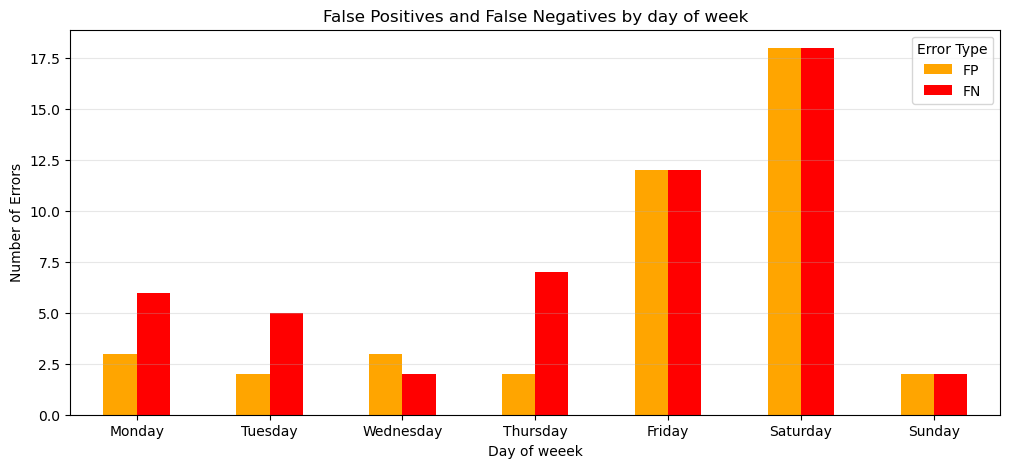

In [105]:

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]


dow_errors = (
    results.groupby(["day_of_week", "error_type"])
    .size()
    .unstack(fill_value=0)
)

dow_errors = dow_errors.reindex(day_order)


# Keep only error types of interest
dow_errors = dow_errors[["FP", "FN"]]

plt.figure(figsize=(12,5))

dow_errors.plot(
    kind="bar",
    figsize=(12,5),
    color={"FP": "orange", "FN": "red"}
)

plt.title("False Positives and False Negatives by day of week")
plt.xlabel("Day of weeek")
plt.ylabel("Number of Errors")
plt.xticks(rotation=0)
plt.legend(title="Error Type")
plt.grid(axis="y", alpha=0.3)

plt.show()

<Figure size 1200x400 with 0 Axes>

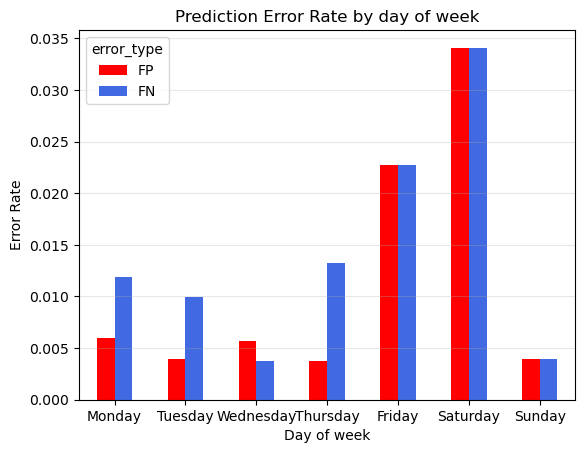

In [110]:

dow_error_rate = (
    results.groupby("day_of_week")["error_type"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(day_order)
)

dow_error_rate = dow_error_rate[["FP", "FN"]]

plt.figure(figsize=(12,4))
dow_error_rate.plot(kind="bar", color=["red","royalblue"])

plt.title("Prediction Error Rate by day of week")
plt.xlabel("Day of week")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

We note that most of the errors occur on Friday and Saturday (end of week). In future, it might be useful to incorporate a feature like "Prediction_day_Fri_or_Sat" and then train.

### Error structure by month

In [112]:
# timestamps actually used by the validation dataloader
val_index = []

for x, y in val_loader:
    decoder_time_idx = x["decoder_time_idx"].cpu().numpy().reshape(-1)
    val_index.extend(decoder_time_idx)

val_index = np.array(val_index)

# Map time_idx back to timestamps
time_map = validation_data.reset_index()[["time_idx", "timestamp_utc"]]
val_timestamps = (
    pd.DataFrame({"time_idx": val_index})
    .merge(time_map, on="time_idx", how="left")["timestamp_utc"]
)

results = pd.DataFrame({
    "timestamp": val_timestamps.values,
    "y_true": y_true.astype(int),
    "prob": probs,
})

results = results.set_index("timestamp")

results["y_pred"] = (results["prob"] >= best_threshold).astype(int)

results["error_type"] = "TN"
results.loc[(results.y_true == 1) & (results.y_pred == 1), "error_type"] = "TP"
results.loc[(results.y_true == 0) & (results.y_pred == 1), "error_type"] = "FP"
results.loc[(results.y_true == 1) & (results.y_pred == 0), "error_type"] = "FN"

results["month"] = results.index.month

In [113]:
results.groupby(["month","error_type"]).size().unstack(fill_value=0)

error_type,FN,FP,TN,TP
month,,,,
7,3,15,693,9
8,15,9,671,49
9,15,12,648,45
10,19,6,690,29
11,0,0,697,0


<Figure size 1200x500 with 0 Axes>

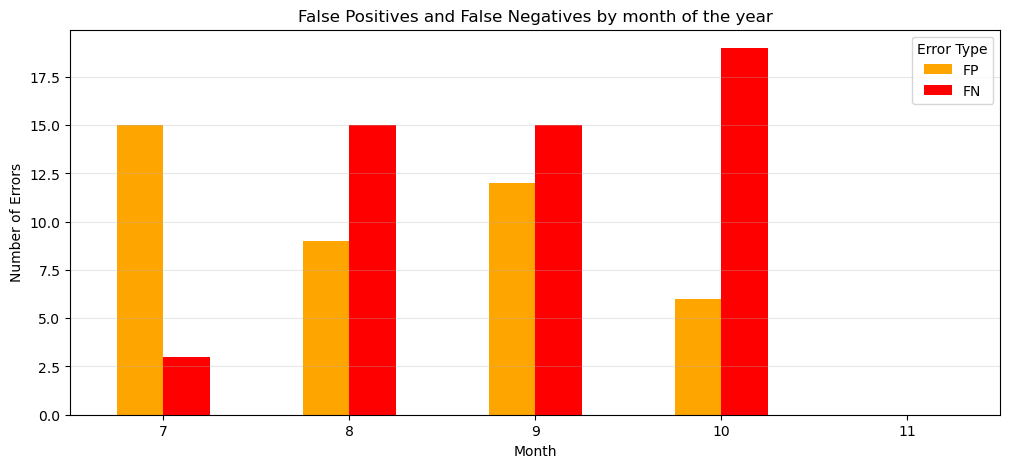

In [114]:

monthly_errors = (
    results.groupby(["month", "error_type"])
    .size()
    .unstack(fill_value=0)
)


monthly_errors = monthly_errors[["FP", "FN"]]

plt.figure(figsize=(12,5))

monthly_errors.plot(
    kind="bar",
    figsize=(12,5),
    color={"FP": "orange", "FN": "red"}
)

plt.title("False Positives and False Negatives by month of the year")
plt.xlabel("Month")
plt.ylabel("Number of Errors")
plt.xticks(rotation=0)
plt.legend(title="Error Type")
plt.grid(axis="y", alpha=0.3)

plt.show()

<Figure size 1200x400 with 0 Axes>

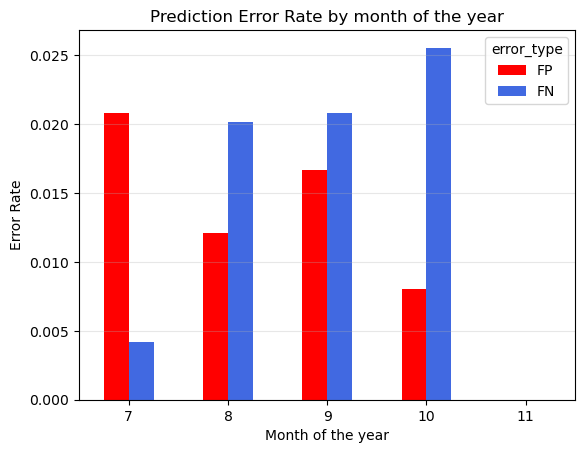

In [117]:

monthly_error_rate = (
    results.groupby("month")["error_type"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

monthly_error_rate = monthly_error_rate[["FP", "FN"]]

plt.figure(figsize=(12,4))
monthly_error_rate.plot(kind="bar", color=["red","royalblue"])

plt.title("Prediction Error Rate by month of the year")
plt.xlabel("Month of the year")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

..


## Feature importance

{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x225 with 1 Axes>,
 'encoder_variables': <Figure size 700x1150 with 1 Axes>,
 'decoder_variables': <Figure size 700x875 with 1 Axes>}

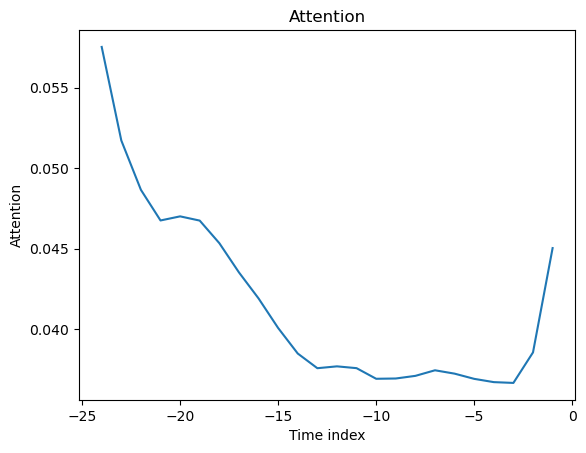

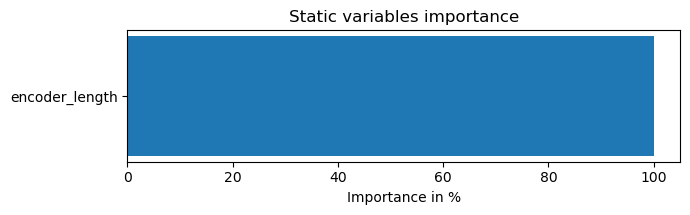

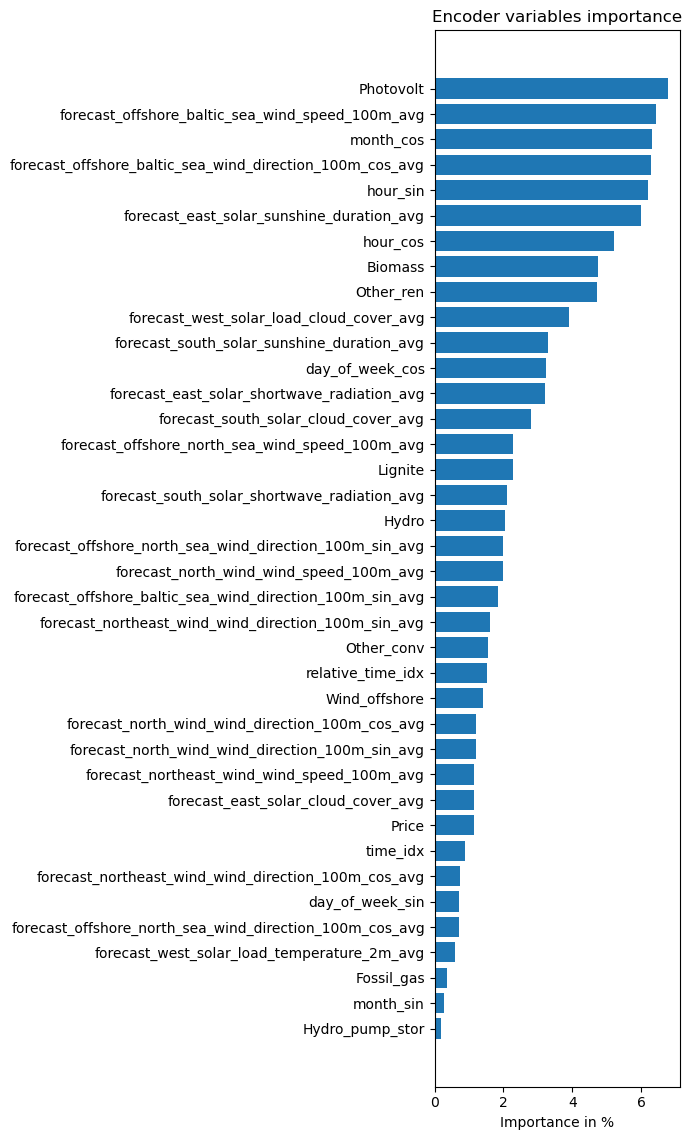

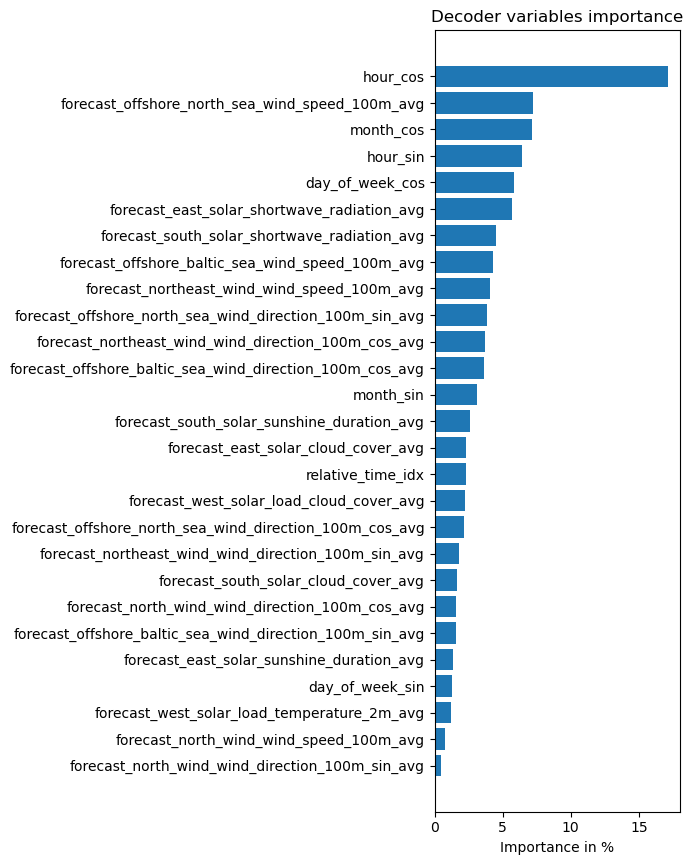

In [118]:
interpretation = best_model.interpret_output(out, reduction="sum")
best_model.plot_interpretation(interpretation)

Looking at the top 10 encoder and decoder variables

In [123]:
print(interpretation["encoder_variables"].shape)
print(len(best_model.encoder_variables))


torch.Size([38])
38


In [124]:
encoder_importance = interpretation["encoder_variables"].detach().cpu().flatten()

k = min(10, len(encoder_importance))

encoder_top10_idx = torch.topk(
    encoder_importance,
    k=k
).indices

encoder_top10 = {
    best_model.encoder_variables[i]: encoder_importance[i].item()
    for i in encoder_top10_idx
}

print(pd.Series(encoder_top10).sort_values(ascending=False))

Photovolt                                                   4.343173
forecast_offshore_baltic_sea_wind_speed_100m_avg            4.121391
month_cos                                                   4.034273
forecast_offshore_baltic_sea_wind_direction_100m_cos_avg    4.026255
hour_sin                                                    3.972244
forecast_east_solar_sunshine_duration_avg                   3.826558
hour_cos                                                    3.341660
Biomass                                                     3.034074
Other_ren                                                   3.011617
forecast_west_solar_load_cloud_cover_avg                    2.494367
dtype: float64


In [125]:
decoder_importance = interpretation["decoder_variables"].detach().cpu().flatten()

k = min(10, len(decoder_importance))

decoder_top10_idx = torch.topk(
    decoder_importance,
    k=k
).indices

decoder_top10 = {
    best_model.decoder_variables[i]: decoder_importance[i].item()
    for i in decoder_top10_idx
}

print(pd.Series(decoder_top10).sort_values(ascending=False))

hour_cos                                                   10.981066
forecast_offshore_north_sea_wind_speed_100m_avg             4.623992
month_cos                                                   4.564068
hour_sin                                                    4.092319
day_of_week_cos                                             3.738315
forecast_east_solar_shortwave_radiation_avg                 3.654065
forecast_south_solar_shortwave_radiation_avg                2.868649
forecast_offshore_baltic_sea_wind_speed_100m_avg            2.759879
forecast_northeast_wind_wind_speed_100m_avg                 2.622517
forecast_offshore_north_sea_wind_direction_100m_sin_avg     2.464380
dtype: float64


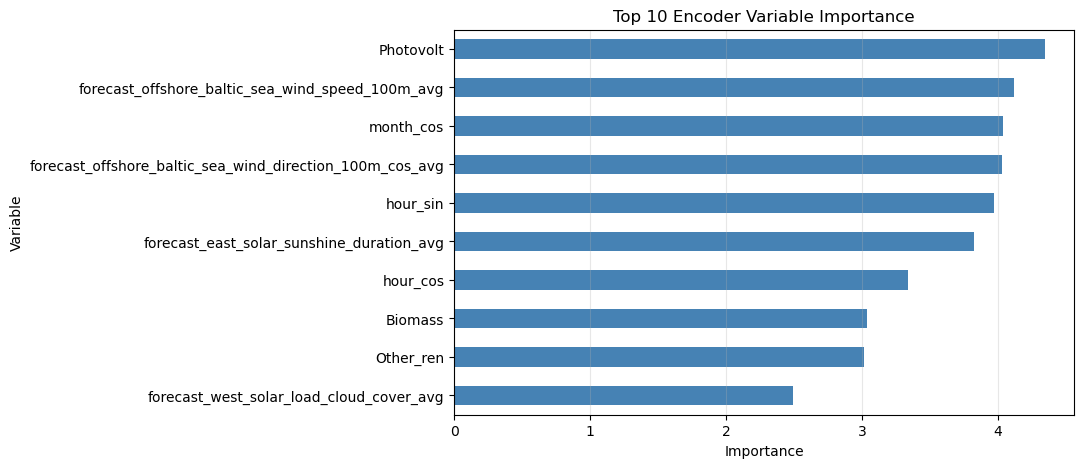

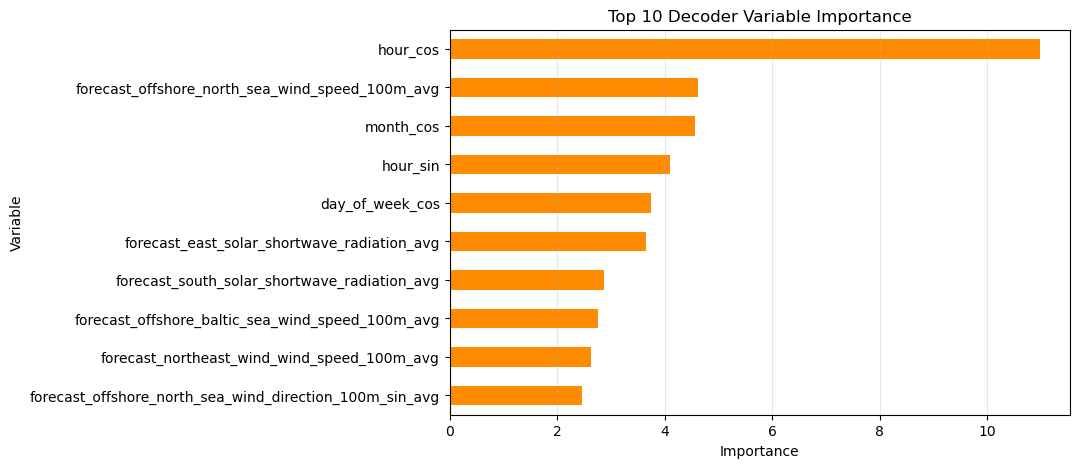

In [126]:

# Encoder plot
encoder_series = pd.Series(encoder_top10).sort_values(ascending=True)

plt.figure(figsize=(8,5))
encoder_series.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Encoder Variable Importance")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.3)
plt.show()


# Decoder plot
decoder_series = pd.Series(decoder_top10).sort_values(ascending=True)

plt.figure(figsize=(8,5))
decoder_series.plot(
    kind="barh",
    color="darkorange"
)

plt.title("Top 10 Decoder Variable Importance")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [127]:
print(best_model.encoder_variables)

['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'forecast_north_wind_wind_speed_100m_avg', 'forecast_north_wind_wind_direction_100m_sin_avg', 'forecast_north_wind_wind_direction_100m_cos_avg', 'forecast_northeast_wind_wind_speed_100m_avg', 'forecast_northeast_wind_wind_direction_100m_sin_avg', 'forecast_northeast_wind_wind_direction_100m_cos_avg', 'forecast_offshore_north_sea_wind_speed_100m_avg', 'forecast_offshore_north_sea_wind_direction_100m_sin_avg', 'forecast_offshore_north_sea_wind_direction_100m_cos_avg', 'forecast_offshore_baltic_sea_wind_speed_100m_avg', 'forecast_offshore_baltic_sea_wind_direction_100m_sin_avg', 'forecast_offshore_baltic_sea_wind_direction_100m_cos_avg', 'forecast_south_solar_shortwave_radiation_avg', 'forecast_south_solar_cloud_cover_avg', 'forecast_south_solar_sunshine_duration_avg', 'forecast_east_solar_shortwave_radiation_avg', 'forecast_east_solar_cloud_cover_avg', 'forecast_east_solar_sunshine_duration_avg', 'fo

## Performance on holdout set

In [78]:

print("test_start:")
print(test_start)

test_start:
2025-12-01 00:00:00+00:00


In [79]:
def build_test_dataset(df_feature, df_forecast, calendar_cols, smard_input_cols, test_start, lookback=24):

    start_date = max(df_feature.index.min(), df_forecast.index.min())

    # all data needed for test horizon
    df = df_feature.loc[start_date:].copy()
    df_weather = df_forecast.loc[start_date:].copy()

    df = df.drop(columns=[c for c in df.columns if c.startswith("observed_")])

    df = df.join(df_weather, how="inner")

    df["target"] = df["Negative_price"].shift(-24)

    forecast_cols = df_forecast.columns
    df[forecast_cols] = df[forecast_cols].shift(-24)

    df = df.dropna(subset=["target"] + list(forecast_cols))

    df = df.loc[:, ~df.columns.duplicated()]

    df = df.drop(columns=["time_idx"], errors="ignore")
    df["time_idx"] = np.arange(len(df))
    df["series"] = 0

    cols = (
        calendar_cols
        + smard_input_cols
        + list(df_forecast.columns)
        + ["time_idx", "series", "target"]
    )

    cols = list(dict.fromkeys(cols))

    df_tft = df[cols]

    test_data = df_tft[
        df_tft.index >= (test_start - pd.Timedelta(hours=lookback))
    ].copy()

    return df_tft, test_data

In [80]:
df_tft_test, test_data = build_test_dataset(
    df_feature_file,
    df_forecast,
    calendar_cols,
    smard_input_cols,
    test_start,
    lookback
)
test_dataset = TimeSeriesDataSet.from_dataset(
    training,
    test_data,
    stop_randomization=True
)

In [143]:
# Extract actual prediction timestamps from test_loader
test_time_idx = []

for x, y in test_loader:
    decoder_time_idx = x["decoder_time_idx"].cpu().numpy().reshape(-1)
    test_time_idx.extend(decoder_time_idx)

test_time_idx = np.array(test_time_idx)

# Map time_idx back to timestamps
time_map = test_data.reset_index()[["time_idx", "timestamp_utc"]]

test_prediction_times = (
    pd.DataFrame({"time_idx": test_time_idx})
    .merge(time_map, on="time_idx", how="left")
)

print("First prediction timestamp:")
print(test_prediction_times["timestamp_utc"].min())

print("\nLast prediction timestamp:")
print(test_prediction_times["timestamp_utc"].max())

print("\nNumber of predictions:")
print(len(test_prediction_times))

First prediction timestamp:
2025-12-01 00:00:00+00:00

Last prediction timestamp:
2026-04-30 03:00:00+00:00

Number of predictions:
3604


In [144]:


# Create test dataloader
test_loader = test_dataset.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=0
)

best_model.eval()

all_probs = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:

        x = {k: v.cpu() for k, v in x.items()}

        logits = best_model(x).prediction.view(-1)
        probs_batch = torch.sigmoid(logits)

        all_probs.append(probs_batch.cpu())
        all_targets.append(y[0].view(-1).cpu())

test_probs = torch.cat(all_probs).numpy()
test_y_true = torch.cat(all_targets).numpy()

# Use the validation-selected threshold (do NOT optimize again on test)
test_preds = (test_probs >= best_threshold).astype(int)

# Metrics
test_roc_auc = roc_auc_score(test_y_true, test_probs)
test_pr_auc = average_precision_score(test_y_true, test_probs)

tn, fp, fn, tp = confusion_matrix(
    test_y_true,
    test_preds
).ravel()

test_precision = tp / (tp + fp + 1e-8)
test_recall = tp / (tp + fn + 1e-8)
test_f1 = 2 * test_precision * test_recall / (test_precision + test_recall + 1e-8)

print(f"ROC AUC      : {test_roc_auc:.6f}")
print(f"PR AUC       : {test_pr_auc:.6f}")
print(f"Threshold    : {best_threshold:.6f}")
print(f"F1           : {test_f1:.6f}")
print(f"Precision    : {test_precision:.6f}")
print(f"Recall       : {test_recall:.6f}")
print(f"Confusion    : TN={tn}, FP={fp}, FN={fn}, TP={tp}")

ROC AUC      : 0.808745
PR AUC       : 0.707496
Threshold    : 0.924425
F1           : 0.698630
Precision    : 0.803150
Recall       : 0.618182
Confusion    : TN=3414, FP=25, FN=63, TP=102
